In [87]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [88]:
df_partida = pd.read_csv("dataset_partida.csv")
df_partida.head()

,x1,x2,resultado
0,-0.125245,0.552601,1
1,0.685084,-0.323315,1
2,0.769488,0.607225,0
3,0.428378,0.157977,1
4,0.075636,0.873185,0


In [89]:
# Definimos X e y, mostramos las columnas y filas

X = df_partida[["x1", "x2"]]
y = df_partida["resultado"]

print(X.shape)
print(y.shape)

(400, 2)
(400,)


In [90]:
# Dividimos y definimos entrenamiento y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (300, 2), Test: (100, 2)


In [91]:
# Escalamos los datos

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
# Creamos el modelo SVC lineal y lo entrenamos

svm_lineal = SVC(kernel="linear", C=0.1, random_state=42)
svm_lineal.fit(X_train_scaled, y_train)

SVC(C=0.1, kernel='linear', random_state=42)

In [93]:
# Evalua el modelo SVM lineal mostrando accuracy, matriz de confusion y metricas detalladas de clasificacion

pred_lineal = svm_lineal.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_lineal)) 
print(confusion_matrix(y_test, pred_lineal))
print(classification_report(y_test, pred_lineal))

Accuracy: 0.94
[[47  3]
 [ 3 47]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.94      0.94      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



In [94]:
# Creamos el modelo SVC rbf y lo entrenamos

svm_rbf = SVC(kernel="rbf", C=0.1, gamma=1.0, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

SVC(C=0.1, gamma=1.0, random_state=42)

In [95]:
# Evalua el modelo SVM rbf mostrando accuracy, matriz de confusion y metricas detalladas de clasificacion

pred_rbf = svm_rbf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))

Accuracy: 0.96
[[47  3]
 [ 1 49]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        50
           1       0.94      0.98      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



In [96]:
# Creamos el modelo SVC poly y lo entrenamos

svm_poly = SVC(kernel="poly", C=0.1, degree=3, coef0=2, random_state=42)
svm_poly.fit(X_train_scaled, y_train)

SVC(C=0.1, coef0=2, kernel='poly', random_state=42)

In [97]:
# Evalua el modelo SVM poly mostrando accuracy, matriz de confusion y metricas detalladas de clasificacion

pred_poly = svm_poly.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_poly))
print(confusion_matrix(y_test, pred_poly))
print(classification_report(y_test, pred_poly))

Accuracy: 0.97
[[48  2]
 [ 1 49]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        50
           1       0.96      0.98      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [98]:
y_pred = svm_poly.predict(X_test_scaled)

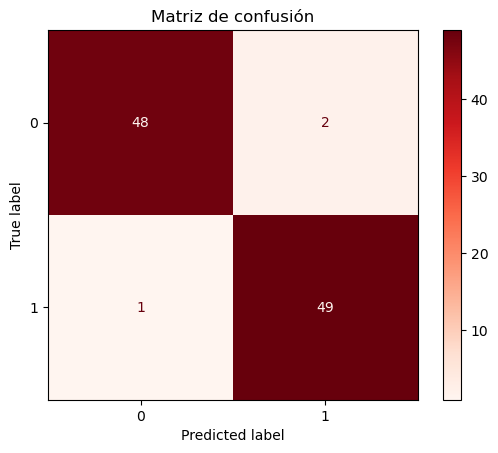

Accuracy:  0.97
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        50
           1       0.96      0.98      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [99]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# Creamos y pintamos la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión")
plt.show()

# Porcentaje de predicciones que hace bien
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

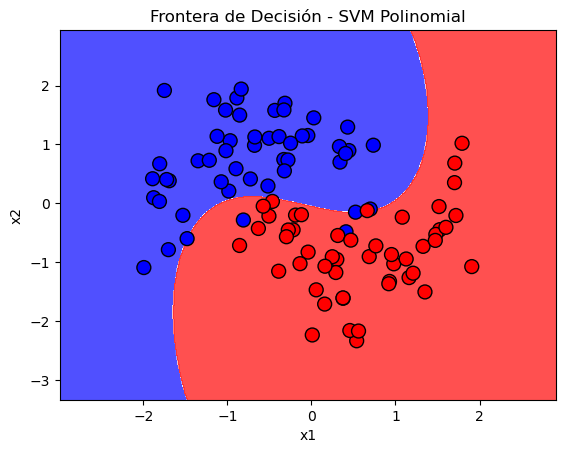

In [100]:
# Dibujamos la frontera de decision del modelo polinomial

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolors='k', marker='o', s=100, cmap='bwr')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Frontera de Decisión - SVM Polinomial')
    plt.show()

plot_decision_boundary(svm_poly, X_test_scaled, y_test.values)

/home/ciabd14/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


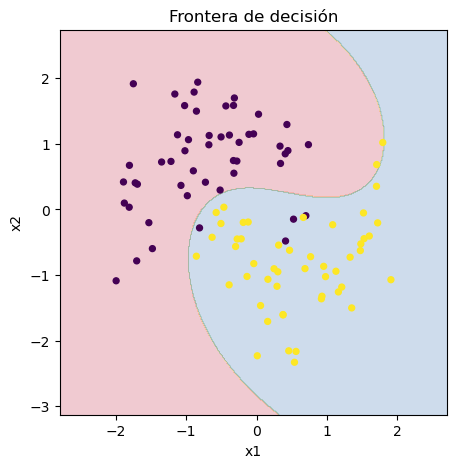

In [101]:
def plot_decision_boundary(model, scaler, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    Z = model.predict(grid_scaled).reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='Spectral')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, )
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary(svm_poly, scaler,X_test_scaled, y_test.values, "Frontera de decisión")

In [102]:

valores_C = [0.1, 1, 5, 10, 50, 100]
valores_gamma = [0.001, 0.01, 0.1, 1]
valores_degree = [2, 3, 4, 5]
valores_coef0 = [0, 0.5, 1, 2]

# Funcion que recibe como parametro el tipo de kernel para entrenar el modelo con distintos hiperparametros almacenados en listas
def mejor_eleccion(kernel):
    mejor_acc = 0
    mejor_config = None

    for C in valores_C:

        # LINEAR
        if kernel == 'linear':
            print(f"\nProbando LINEAR | C={C}")

            svm = SVC(kernel='linear', C=C, random_state=42)

            svm.fit(X_train_scaled, y_train)
            pred = svm.predict(X_test_scaled)
            acc = accuracy_score(y_test, pred)

            print(f"Accuracy: {acc:.4f}")

            if acc > mejor_acc:
                mejor_acc = acc
                mejor_config = ('linear', C)

        # RBF
        elif kernel == 'rbf':
            for gamma in valores_gamma:
                print(f"\nProbando RBF | C={C} | gamma={gamma}")

                svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)

                svm.fit(X_train_scaled, y_train)
                pred = svm.predict(X_test_scaled)
                acc = accuracy_score(y_test, pred)

                print(f"Accuracy: {acc:.4f}")

                if acc > mejor_acc:
                    mejor_acc = acc
                    mejor_config = ('rbf', C, gamma)

        # POLY 
        elif kernel == 'poly':
            for degree in valores_degree:
                for coef0 in valores_coef0:
                    print(f"\nProbando POLY | C={C} | degree={degree} | coef0={coef0}")

                    svm = SVC(kernel='poly', C=C, degree=degree, coef0=coef0, random_state=42)

                    svm.fit(X_train_scaled, y_train)
                    pred = svm.predict(X_test_scaled)
                    acc = accuracy_score(y_test, pred)

                    print(f"Accuracy: {acc:.4f}")

                    if acc > mejor_acc:
                        mejor_acc = acc
                        mejor_config = ('poly', C, degree, coef0)

    print(f"\nMejor Accuracy: {mejor_acc:.4f}")
    print(f"Mejor configuración: {mejor_config}")


In [103]:
mejor_eleccion("poly")


Probando POLY | C=0.1 | degree=2 | coef0=0
Accuracy: 0.5300

Probando POLY | C=0.1 | degree=2 | coef0=0.5
Accuracy: 0.9200

Probando POLY | C=0.1 | degree=2 | coef0=1
Accuracy: 0.9200

Probando POLY | C=0.1 | degree=2 | coef0=2
Accuracy: 0.9200

Probando POLY | C=0.1 | degree=3 | coef0=0
Accuracy: 0.8700

Probando POLY | C=0.1 | degree=3 | coef0=0.5
Accuracy: 0.9600

Probando POLY | C=0.1 | degree=3 | coef0=1
Accuracy: 0.9600

Probando POLY | C=0.1 | degree=3 | coef0=2
Accuracy: 0.9700

Probando POLY | C=0.1 | degree=4 | coef0=0
Accuracy: 0.5200

Probando POLY | C=0.1 | degree=4 | coef0=0.5
Accuracy: 0.9500

Probando POLY | C=0.1 | degree=4 | coef0=1
Accuracy: 0.9700

Probando POLY | C=0.1 | degree=4 | coef0=2
Accuracy: 0.9400

Probando POLY | C=0.1 | degree=5 | coef0=0
Accuracy: 0.8800

Probando POLY | C=0.1 | degree=5 | coef0=0.5
Accuracy: 0.9400

Probando POLY | C=0.1 | degree=5 | coef0=1
Accuracy: 0.9400

Probando POLY | C=0.1 | degree=5 | coef0=2
Accuracy: 0.9300

Probando POLY |

1. Estudio de la estructura del dataset:
- Número de variables y tipo de datos.

En este dataset tenemos tres variables (x1, x2 y resultado), siendo estas de tipo numerico.

- Variable objetivo y naturaleza del problema.

La variable objetivo es resultado (0 o 1). Se trata de un problema de clasificacion binaria, donde el 
objetivo es predecir a que clase pertenece cada muestra basandose en las dos caracteristicas (x1, x2).

2. Justificación del enfoque elegido:
- Argumentación sobre los modelos considerados adecuados.

Se ha elegido Support Vector Machines (SVM) con diferentes kernels por las siguientes razones:

- Problema de clasificación binaria: SVM es especialmente efectivo en este tipo de problemas
- Flexibilidad: Los diferentes kernels (linear, RBF, poly) permiten capturar diferentes tipos de relaciones:

- Linear: para fronteras de decisión lineales
- RBF: para fronteras no lineales complejas
- Polynomial: para relaciones polinómicas entre las variables

Descarte razonado de otros enfoques, si procede.

- SVM se justifica por su capacidad de manejar fronteras no lineales mediante kernels, su robustez 
con datasets pequeños y su buen comportamiento con datos escalados.

3. Entrenamiento y evaluación de los modelos seleccionados:
- Uso de métricas adecuadas al problema.

Se utilizo Accuracy (exactitud) como metrica principal, que es apropiada para este problema de 
clasificacion binaria balanceada.

- Comparación razonada de resultados.

LINEAL(C=0.1)
RBF(C=0.1, gamma=1)
POLY(C=0.1, degree=3, coef0=2)

4. Valoración final:
- Limitaciones del modelo.

Dataset pequeño, sensibilidad a hiperparametros (pequeños cambios en gamma y C afectan significativamente el rendimiento)

- Posibles mejoras o líneas de trabajo futuras.

Estudio de la matriz de confusión, identificar qué tipo de errores comete el modelo (falsos positivos vs falsos negativos) y aumentar el dataset
